
========== COLUMNS ==========
['Student ID', 'Student Name', 'Gender', 'Age', 'Study Hours', 'Attendance', 'Previous Score', 'Assignment Score', 'Mid Term Score', 'Final Score', 'Extracurricular', 'Internet Access']

========== DATASET ==========
  Student ID  Student Name  Gender  Age  Study Hours  Attendance  \
0     STU001  Aarav Sharma    Male   18          4.5          87   
1     STU002  Ananya Patel  Female   19          6.0          92   
2     STU003   Rahul Kumar    Male   17          3.0          75   
3     STU004   Priya Singh  Female   18          7.0          95   
4     STU005   Rohan Verma    Male   20          2.5          68   

   Previous Score  Assignment Score  Mid Term Score  Final Score  \
0              72                81              76           62   
1              85                89              88           84   
2              64                70              68           56   
3              91                94              90           74   
4  

C:\Users\ersha\AppData\Local\Temp\ipykernel_4604\2798245281.py:77: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_columns = df.select_dtypes(


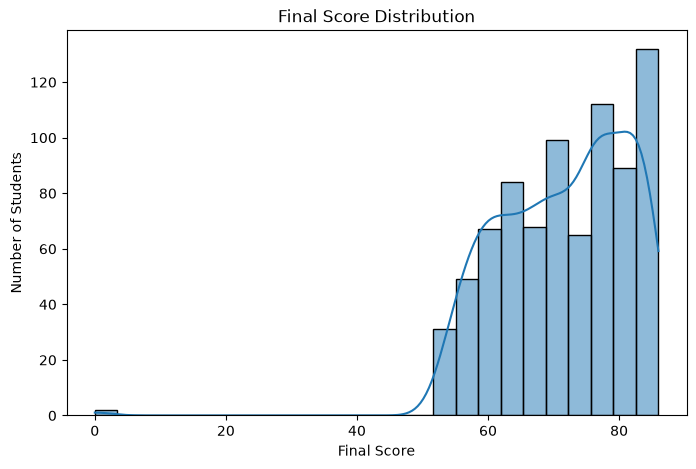

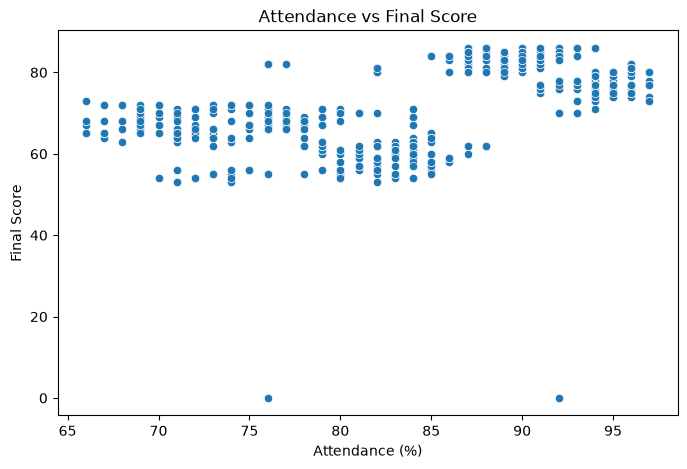

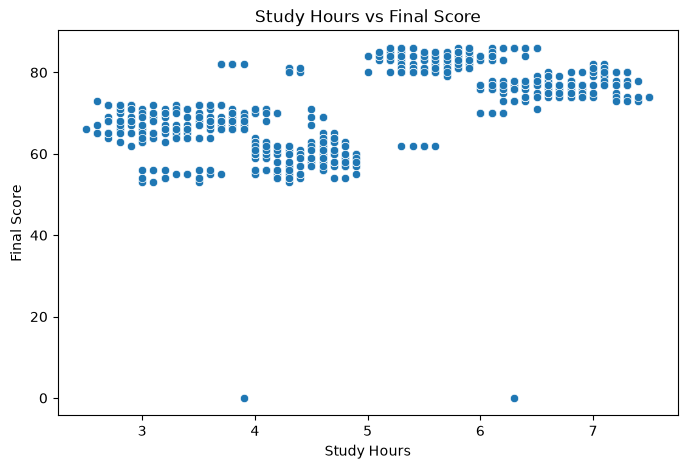

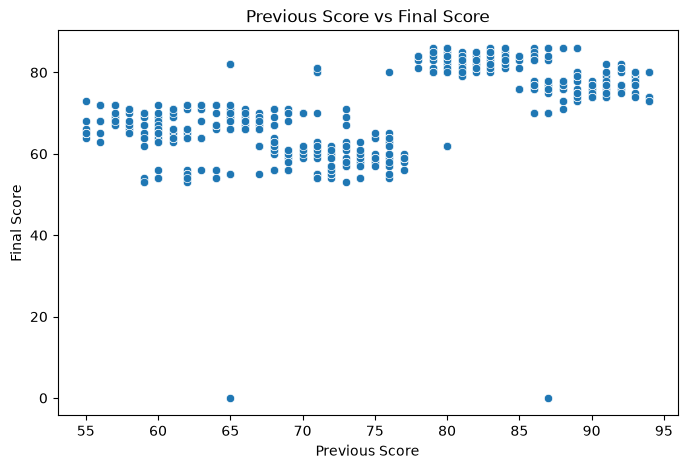

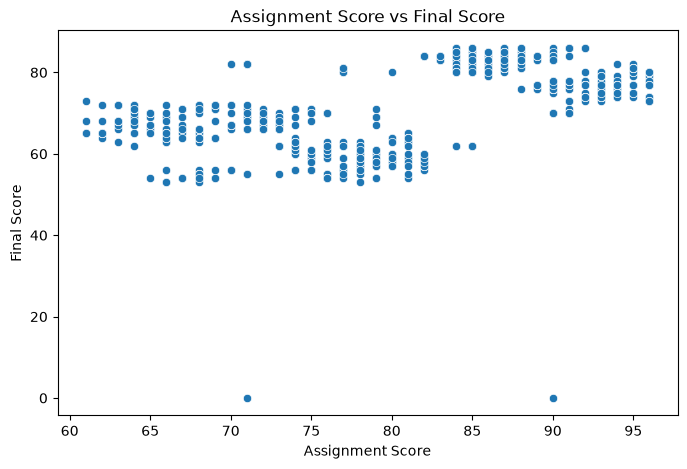

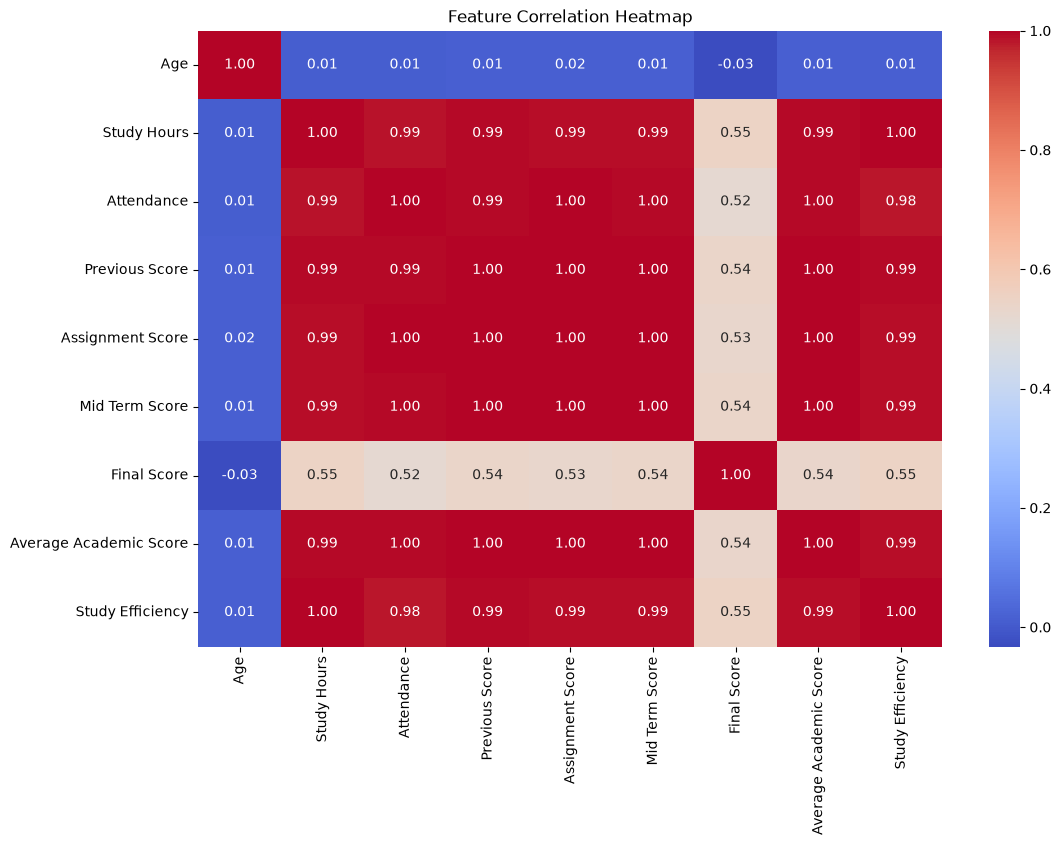

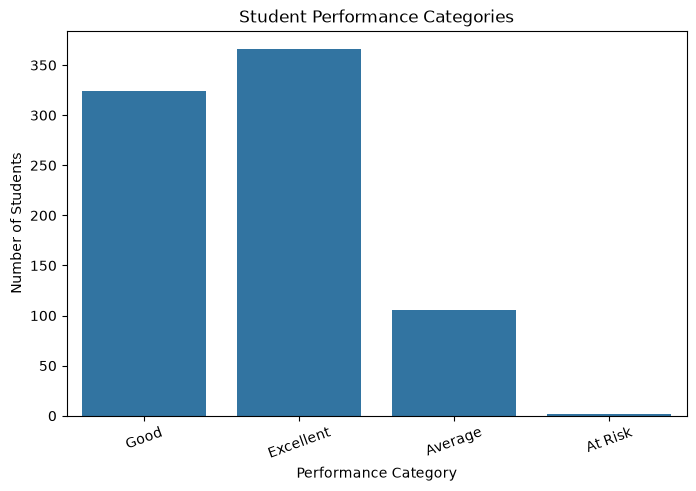

C:\Users\ersha\AppData\Local\Temp\ipykernel_4604\2798245281.py:301: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_features = X.select_dtypes(



========== TRAIN TEST DATA ==========
Training Data: (638, 11)
Testing Data: (160, 11)

Training: Linear Regression

Training: Decision Tree

Training: Random Forest

Training: XGBoost

========== MODEL COMPARISON ==========
               Model    MAE     MSE   RMSE  R2 Score
3            XGBoost  2.846  49.396  7.028     0.584
2      Random Forest  2.733  49.611  7.043     0.582
1      Decision Tree  2.881  51.491  7.176     0.566
0  Linear Regression  3.747  52.792  7.266     0.555

========== BEST MODEL ==========
Best Model: XGBoost
R2 Score: 0.584

========== FEATURE IMPORTANCE ==========
                   Feature  Importance
0                   Gender    0.922616
2              Study Hours    0.014057
4           Previous Score    0.011980
8          Internet Access    0.010846
7          Extracurricular    0.010525
1                      Age    0.007284
5         Assignment Score    0.005656
9   Average Academic Score    0.005069
10        Study Efficiency    0.004940
6      

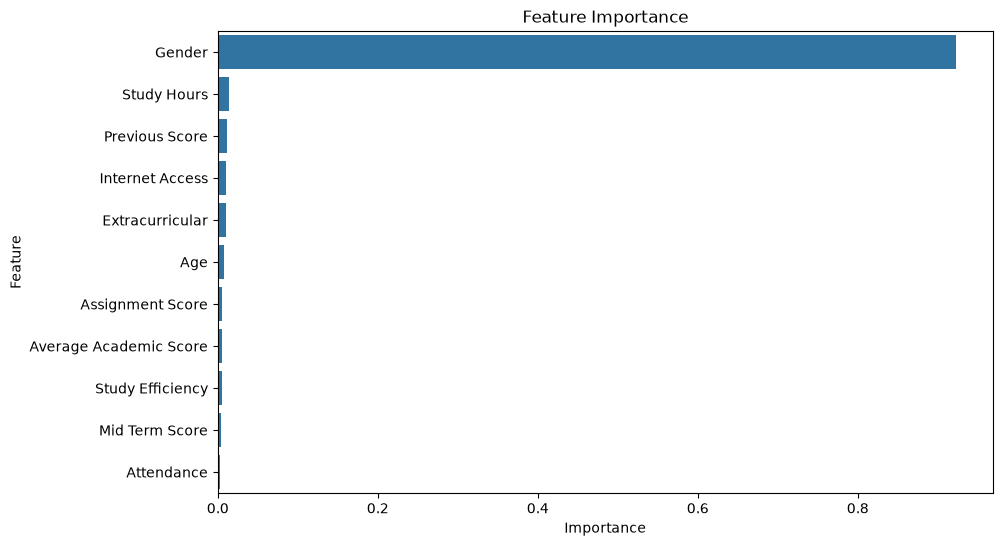

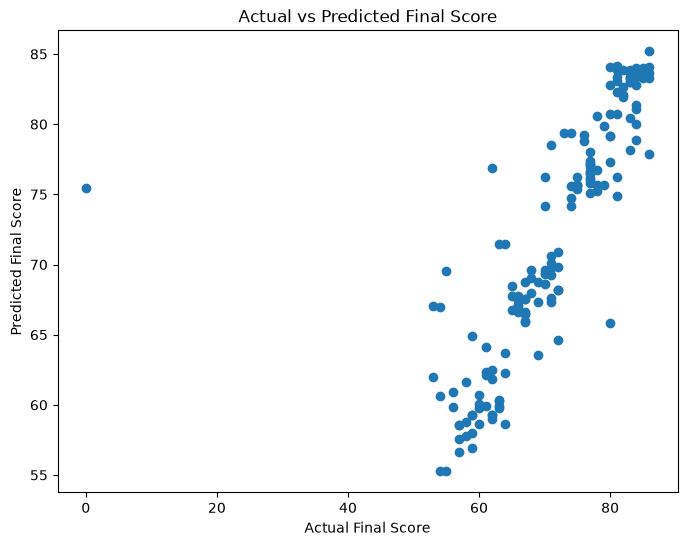


Best model saved as: student_performance_model.pkl
Processed dataset saved successfully.

========== AT-RISK STUDENTS ==========
    Student ID   Student Name  Attendance  Study Hours  Final Score
796     STU797  Hemant Sharma          76          3.9            0
797     STU798    Jyoti Patel          92          6.3            0

========== TOP 10 STUDENTS ==========
    Student ID   Student Name  Final Score Performance Category
113     STU114  Simran Sharma           86            Excellent
393     STU394  Roshni Sharma           86            Excellent
93      STU094   Roshni Patel           86            Excellent
267     STU268    Kavya Patel           86            Excellent
431     STU432   Sakshi Verma           86            Excellent
227     STU228  Shruti Sharma           86            Excellent
201     STU202     Isha Kumar           86            Excellent
313     STU314   Simran Kumar           86            Excellent
731     STU732   Sakshi Kumar           86         

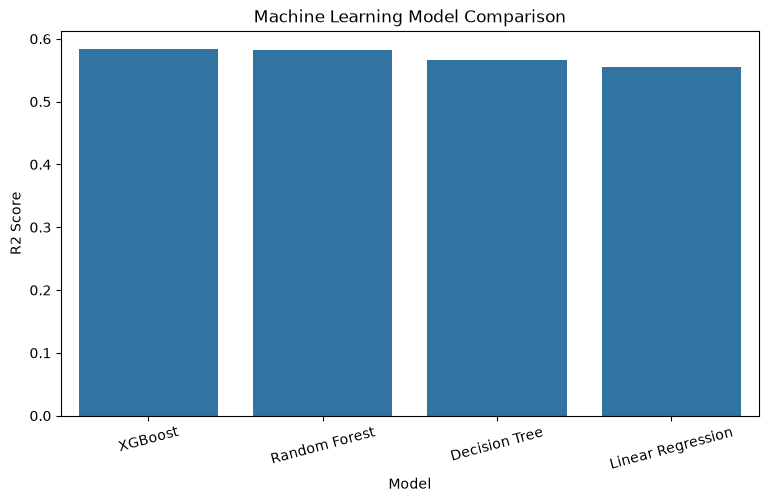


       STUDENT PERFORMANCE PREDICTION
Predicted Final Score: 60.13
Performance Category: Good

       PROJECT COMPLETED SUCCESSFULLY

Total Students: 798
Average Final Score: 71.61
Best Model: XGBoost
Best R2 Score: 0.584

All files saved successfully.


In [1]:


                    # ============ STUDENT PERFORMANCE ANALYSIS & PREDICTION ============



import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor


#============ READ DATA ============ 

df = pd.read_excel(r"C:\Users\ersha\Desktop\project 1 n\student_performance_data.xlsx.xlsx")

print("\n========== COLUMNS ==========")
print(df.columns.tolist())

print("\n========== DATASET ==========")
print(df.head())

print("\n========== DATASET SHAPE ==========")
print(df.shape)

print("\n========== DATA TYPES ==========")
print(df.dtypes)



# ============  BASIC DATA ANALYSIS ============ 

print("\n========== STATISTICAL SUMMARY ==========")
print(df.describe())

print("\n========== MISSING VALUES ==========")
print(df.isnull().sum())

print("\n========== DUPLICATES ==========")
print(df.duplicated().sum())



#  REMOVE DUPLICATES


df = df.drop_duplicates()

print("\nDuplicates removed.")
print("New shape:", df.shape)


# ============  HANDLE MISSING VALUES ============ 


numeric_columns = df.select_dtypes(
    include=["int64", "float64"]
).columns

for column in numeric_columns:
    df[column] = df[column].fillna(
        df[column].median()
    )


categorical_columns = df.select_dtypes(
    include=["object"]
).columns

for column in categorical_columns:
    df[column] = df[column].fillna(
        df[column].mode()[0]
    )


print("\n========== MISSING VALUES AFTER CLEANING ==========")
print(df.isnull().sum())


# ============  FEATURE ENGINEERING ============ 

df["Average Academic Score"] = (
    df["Previous Score"]
    + df["Assignment Score"]
    + df["Mid Term Score"]
) / 3


df["Study Efficiency"] = (
    df["Study Hours"]
    * df["Attendance"]
) / 100


print("\n========== FEATURE ENGINEERING ==========")

print(
    df[
        [
            "Average Academic Score",
            "Study Efficiency"
        ]
    ].head()
)



# ============  PERFORMANCE CATEGORY ============ 

def performance_category(score):

    if score >= 75:
        return "Excellent"

    elif score >= 60:
        return "Good"

    elif score >= 50:
        return "Average"

    elif score >= 40:
        return "Below Average"

    else:
        return "At Risk"


df["Performance Category"] = (
    df["Final Score"]
    .apply(performance_category)
)

# ============  EXPLORATORY DATA ANALYSIS ============ 


plt.figure(figsize = (8,5))

sns.histplot(
    df["Final Score"],
    kde=True
)

plt.title("Final Score Distribution")
plt.xlabel("Final Score")
plt.ylabel("Number of Students")

plt.show()



#  ============ ATTENDANCE VS FINAL SCORE ============ 

plt.figure(figsize=(8, 5))

sns.scatterplot(
    data=df,
    x="Attendance",
    y="Final Score"
)

plt.title("Attendance vs Final Score")
plt.xlabel("Attendance (%)")
plt.ylabel("Final Score")

plt.show()



# ============  STUDY HOURS VS FINAL SCORE ============ 
 

plt.figure(figsize=(8, 5))

sns.scatterplot(
    data=df,
    x="Study Hours",
    y="Final Score"
)

plt.title("Study Hours vs Final Score")
plt.xlabel("Study Hours")
plt.ylabel("Final Score")

plt.show()



# ============  PREVIOUS SCORE VS FINAL SCORE ============ 


plt.figure(figsize=(8, 5))

sns.scatterplot(
    data=df,
    x="Previous Score",
    y="Final Score"
)

plt.title("Previous Score vs Final Score")
plt.xlabel("Previous Score")
plt.ylabel("Final Score")

plt.show()



#  ============ ASSIGNMENT SCORE VS FINAL SCORE ============


plt.figure(figsize=(8, 5))

sns.scatterplot(
    data=df,
    x="Assignment Score",
    y="Final Score"
)

plt.title("Assignment Score vs Final Score")
plt.xlabel("Assignment Score")
plt.ylabel("Final Score")

plt.show()



# ============  CORRELATION HEATMAP ============


plt.figure(figsize=(12, 8))

correlation = df.corr(
    numeric_only=True
)

sns.heatmap(
    correlation,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Feature Correlation Heatmap")

plt.show()



# ============ PERFORMANCE CATEGORY GRAPH ============


plt.figure(figsize=(8, 5))

sns.countplot(
    data=df,
    x="Performance Category"
)

plt.title("Student Performance Categories")
plt.xlabel("Performance Category")
plt.ylabel("Number of Students")

plt.xticks(rotation=20)

plt.show()



# ============ PREPARE DATA FOR MACHINE LEARNING ============


X = df.drop(
    columns=[
        "Final Score",
        "Student ID",
        "Student Name",
        "Performance Category"
    ],
    errors="ignore"
)

y = df["Final Score"]



# ============ ENCODE CATEGORICAL VARIABLES ============


label_encoders = {}

categorical_features = X.select_dtypes(
    include=["object"]
).columns


for column in categorical_features:

    encoder = LabelEncoder()

    X[column] = encoder.fit_transform(
        X[column].astype(str)
    )

    label_encoders[column] = encoder



# ============ TRAIN TEST SPLIT ============


X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)


print("\n========== TRAIN TEST DATA ==========")

print(
    "Training Data:",
    X_train.shape
)

print(
    "Testing Data:",
    X_test.shape
)



# ============ CREATE MACHINE LEARNING MODELS ============


models = {

    "Linear Regression":
        LinearRegression(),

    "Decision Tree":
        DecisionTreeRegressor(
            random_state=42
        ),

    "Random Forest":
        RandomForestRegressor(
            n_estimators=200,
            random_state=42
        ),

    "XGBoost":
        XGBRegressor(
            n_estimators=200,
            max_depth=5,
            learning_rate=0.05,
            random_state=42
        )
}



#  ============ TRAIN AND EVALUATE MODELS ============


results = []

trained_models = {}


for name, model in models.items():

    print("\nTraining:", name)

    model.fit(
        X_train,
        y_train
    )

    predictions = model.predict(
        X_test
    )

    mae = mean_absolute_error(
        y_test,
        predictions
    )

    mse = mean_squared_error(
        y_test,
        predictions
    )

    rmse = np.sqrt(mse)

    r2 = r2_score(
        y_test,
        predictions
    )

    results.append({

        "Model": name,
        "MAE": mae,
        "MSE": mse,
        "RMSE": rmse,
        "R2 Score": r2

    })

    trained_models[name] = model



#  ============ MODEL COMPARISON ============


results_df = pd.DataFrame(results)

results_df = results_df.sort_values(
    by="R2 Score",
    ascending=False
)


print(
    "\n========== MODEL COMPARISON =========="
)

print(
    results_df.round(3)
)



# ============  SELECT BEST MODEL ============


best_model_name = results_df.iloc[0]["Model"]

best_model = trained_models[
    best_model_name
]


print(
    "\n========== BEST MODEL =========="
)

print(
    "Best Model:",
    best_model_name
)

print(
    "R2 Score:",
    round(
        results_df.iloc[0]["R2 Score"],
        3
    )
)



#  ============ FEATURE IMPORTANCE ============


if hasattr(
    best_model,
    "feature_importances_"
):

    importance = pd.DataFrame({

        "Feature": X.columns,

        "Importance":
            best_model.feature_importances_

    })


    importance = importance.sort_values(
        by="Importance",
        ascending=False
    )


    print(
        "\n========== FEATURE IMPORTANCE =========="
    )

    print(
        importance
    )


    plt.figure(figsize=(10, 6))

    sns.barplot(
        data=importance,
        x="Importance",
        y="Feature"
    )

    plt.title("Feature Importance")

    plt.show()



# ============ ACTUAL VS PREDICTED ============


final_predictions = best_model.predict(
    X_test
)


plt.figure(figsize=(8, 6))

plt.scatter(
    y_test,
    final_predictions
)

plt.xlabel("Actual Final Score")
plt.ylabel("Predicted Final Score")

plt.title(
    "Actual vs Predicted Final Score"
)

plt.show()



#  ============ SAVE BEST MODEL ============


model_data = {

    "model": best_model,

    "columns": X.columns.tolist(),

    "label_encoders": label_encoders

}


joblib.dump(
    model_data,
    "student_performance_model.pkl"
)


print(
    "\nBest model saved as:"
    " student_performance_model.pkl"
)


# ============  SAVE PROCESSED DATA ============


df.to_csv(
    "processed_student_data.csv",
    index=False
)


print(
    "Processed dataset saved successfully."
)



# ============  AT-RISK STUDENTS ============


at_risk = df[
    df["Final Score"] < 40
]


print(
    "\n========== AT-RISK STUDENTS =========="
)


if len(at_risk) > 0:

    print(
        at_risk[
            [
                "Student ID",
                "Student Name",
                "Attendance",
                "Study Hours",
                "Final Score"
            ]
        ]
    )

else:

    print(
        "No At-Risk students found."
    )



# ============ TOP 10 STUDENTS ============ 

top_students = df.sort_values(
    by="Final Score",
    ascending=False
).head(10)


print(
    "\n========== TOP 10 STUDENTS =========="
)


print(
    top_students[
        [
            "Student ID",
            "Student Name",
            "Final Score",
            "Performance Category"
        ]
    ]
)



# ============  MODEL PERFORMANCE GRAPH ============


plt.figure(figsize=(9, 5))

sns.barplot(
    data=results_df,
    x="Model",
    y="R2 Score"
)

plt.title(
    "Machine Learning Model Comparison"
)

plt.xlabel("Model")
plt.ylabel("R2 Score")

plt.xticks(rotation=15)

plt.show()



# ============  NEW STUDENT PREDICTION  ============


# New student details

new_student = pd.DataFrame([{

    "Gender": "Male",

    "Age": 19,

    "Study Hours": 6,

    "Attendance": 90,

    "Previous Score": 80,

    "Assignment Score": 85,

    "Mid Term Score": 82,

    "Extracurricular": "Yes",

    "Internet Access": "Yes"

}])


# Feature engineering for new student

new_student["Average Academic Score"] = (
    new_student["Previous Score"]
    + new_student["Assignment Score"]
    + new_student["Mid Term Score"]
) / 3


new_student["Study Efficiency"] = (
    new_student["Study Hours"]
    * new_student["Attendance"]
) / 100


# Encode categorical columns

for column, encoder in label_encoders.items():

    if column in new_student.columns:

        new_student[column] = encoder.transform(
            new_student[column].astype(str)
        )


# Match training columns

new_student = new_student.reindex(
    columns=X.columns,
    fill_value=0
)


# Predict

prediction = best_model.predict(
    new_student
)[0]


# Performance category

category = performance_category(
    prediction
)



# ============  DISPLAY FINAL PREDICTION ============


print(
    "\n========================================"
)

print(
    "       STUDENT PERFORMANCE PREDICTION"
)

print(
    "========================================"
)

print(
    "Predicted Final Score:",
    round(prediction, 2)
)

print(
    "Performance Category:",
    category
)

print(
    "========================================"
)



# ============ PROJECT SUMMARY ============


print(
    "\n========================================"
)

print(
    "       PROJECT COMPLETED SUCCESSFULLY"
)

print(
    "========================================"
)

print(
    "\nTotal Students:",
    len(df)
)

print(
    "Average Final Score:",
    round(
        df["Final Score"].mean(),
        2
    )
)

print(
    "Best Model:",
    best_model_name
)

print(
    "Best R2 Score:",
    round(
        results_df.iloc[0]["R2 Score"],
        3
    )
)

print(
    "\nAll files saved successfully."
)

print(
    "========================================"
)